# Scratch Implementations

## Linear Regression

In [13]:
import numpy as np

In [14]:
class LinearRegression:
    def __init__ (self,learning_rate = 0.01, n_iter =10000):
        self.bias = None
        self.weights = None
        self.lr = learning_rate
        self.n_iter = n_iter
        
    def fit(self,X,y):
        m, n = X.shape
        self.bias = 0
        self.weights = np.zeros(n)

        for i in range(self.n_iter):
            y_pred = self.bias + np.dot(X,self.weights) 
            db = (1/m) * np.sum(y_pred - y)
            dw = (1/m) * np.dot(X.T, y_pred-y)
            
            self.bias -= self.lr * db
            self.weights -= self.lr * dw
        
    def predict(self,X):
        y_pred = self.bias + np.dot(X, self.weights)
        return y_pred

In [15]:
X = np.array([[1],[2],[3],[4],[5]])
y = np.array([2, 4, 6, 8, 10])

In [16]:
model = LinearRegression()
model.fit(X,y)

y_pred = model.predict(X)
print(y_pred)

[2.00000002 4.00000001 6.         8.         9.99999999]


We can also implement linear regression with OLS(Ordinary Least Squares) for small data sets.
Normal Equation ->  theta = inverse(X.T * X) * X.T * y

In [25]:
class LinearRegressionOLS:
    def __init__ (self,learning_rate = 0.01, n_iter =10000):
        self.bias = None
        self.weights = None
        self.lr = learning_rate
        self.n_iter = n_iter
        
    def fit(self,X,y):
        m, n = X.shape
        X_b = np.c_[np.ones((m,1)),X]
        
        theta = np.dot(np.linalg.inv(np.dot(X_b.T, X_b)), np.dot(X_b.T, y))
        #theta = np.linealg.inv(X_b.T @ X_b) @ (X.T @ y)

        self.bias = theta[0]
        self.weights = theta[1:]
        
    def predict(self,X):
        y_pred = self.bias + np.dot(X, self.weights)
        return y_pred

In [26]:
model = LinearRegressionOLS()
model.fit(X,y)

y_pred = model.predict(X)
print(y_pred)

[ 2.  4.  6.  8. 10.]


## Logistic Regression

In [27]:
# Logistic Regression

class LogisticRegression:
    def __init__(self, learning_rate=0.1, n_iter=1000):
        self.bias = None
        self.weights = None
        self.lr = learning_rate
        self.n_iter = n_iter

    def _sigmoid(self, z):
        return (1 / (1 + np.exp(-z)))

    def fit(self, X, y):
        m, n = X.shape

        self.bias = 0
        self.weights = np.zeros(n)

        for i in range(self.n_iter):
            z = self.bias + np.dot(X, self.weights)
            y_pred = self._sigmoid(z)

            db = (1/m) * (y_pred - y)
            dw = (1/m) * np.dot(X.T, (y_pred - y))
            
            self.bias -= self.lr * db
            self.weights -= self.lr * dw
    
    def get_probabilities(self, X):
        z = self.bias + np.dot(X, self.weights)
        return self._sigmoid(z)
        
    def predict(self, X, threshold=0.5):
        probabilities = self.get_probabilities(X)
        y_pred_bool = probabilities >= threshold
        return y_pred_bool.astype(int)

In [28]:
X = np.array([[1, 2], [2, 3], [3, 4], [4, 5]])
y = np.array([0, 0, 1, 1])

model = LogisticRegression()
model.fit(X, y)

y_pred = model.predict(X)
print(y_pred)

print(model.get_probabilities(X))

[0 0 1 1]
[0.03701722 0.04694058 0.972997   0.98153106]


## KNN Classifer

In [29]:
class KNNClassifier:
    def __init__(self, k=3):
        self.k = k
    
    def _euclidean_dist(self, x1, x2):
        return np.sqrt(np.sum((x1 - x2) ** 2))
    
    def fit(self, X, y): # Lazy Learner
        self.X_train = X
        self.y_train = y

    def _predict_one(self, x):
        distances = [self._euclidean_dist(x, x_train) for x_train in self.X_train]

        knn_indices = np.argsort(distances)[:self.k]

        knn_classes = [self.y_train[i] for i in knn_indices]

        majority_class = np.argmax(np.bincount(knn_classes))
        return majority_class

    def predict(self, X):
        y_pred = [self._predict_one(x) for x in X]
        return np.array(y_pred)

In [30]:
# Data
X_train = np.array([
    [1, 2],
    [2, 3],
    [3, 3],
    [6, 5],
    [7, 7]
])

y_train = np.array([0, 0, 0, 1, 1])

X_test = np.array([
    [2, 2],
    [6, 6]
])

model = KNNClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(y_pred)

[0 1]


<Axes: xlabel='x1', ylabel='x2'>

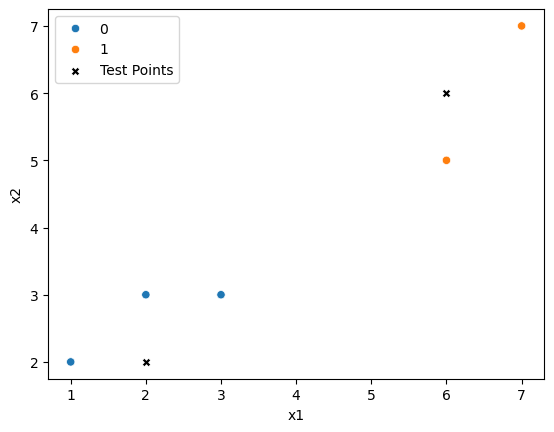

In [32]:
# Visualize
import pandas as pd
import seaborn as sns

X_train_df = pd.DataFrame(X_train, columns=["x1", "x2"])
X_train_df["label"] = y_train

sns.scatterplot(
    data=X_train_df,
    x="x1",
    y="x2",
    hue="label"
)

X_test_df = pd.DataFrame(X_test, columns=["x1", "x2"])

sns.scatterplot(
    data=X_test_df,
    x="x1",
    y="x2",
    color="black",
    marker="X",
    label="Test Points"
)

## KNN Regressor

In [37]:
class KNNRegressor:
    def __init__(self, k=3):
        self.k = k
    
    def _eu_dist(self, x1, x2):
        return np.sqrt(np.sum((x1 - x2) ** 2))
    
    def fit(self, X, y): # Lazy Learner
        self.X_train = X
        self.y_train = y

    def _predict_one(self, x):
        distances=[self._eu_dist(x,x_train) for x_train in self.X_train]

        k_indices = np.argsort(distances)[:self.k]

        k_nearest_values = self.y_train[k_indices]
        return np.mean(k_nearest_values)

    def predict(self, X):
        y_pred = [self._predict_one(x) for x in X]
        return np.array(y_pred)

In [38]:
# Training data
X_train = np.array([[1], [2], [3], [4], [5]])
y_train = np.array([2, 4, 6, 8, 10])

# Test data
X_test = np.array([[1.5], [3.5], [6]])

# Create and train model
knn = KNNRegressor(k=3)
knn.fit(X_train, y_train)

# Predict
y_pred = knn.predict(X_test)
print("Predictions:", y_pred)


Predictions: [4. 6. 8.]
